In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from matplotlib.lines import Line2D
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm import tqdm

plt.rcParams.update({'font.size': 20})
sns.set_style("darkgrid")

In [4]:
df_x = pd.read_csv('../dataset/0-original/X.csv').drop('id', axis=1)

## Multicollinearity test using VIF

*np* and *ng* are strongly inversely correlated.

#### $$np\approx  -1.06\times ng + 165$$

Why "inversely"?

Think of the engine like a shared power source with two "users" — the rotor and the compressor:

    When the rotor draws a lot of power (like adding load to an electric generator), there’s less left for the compressor.
    When the rotor draws little power, the compressor can "take more" of the engine's energy.

In [5]:
def calculate_vif(data, samples=10_000):
    vif_df = data.assign(const=1)
    vif = []
    for i in tqdm(range(vif_df.shape[1])):
        vif.append(variance_inflation_factor(vif_df.values[:samples], i))

    vif_data = pd.Series(vif, index=vif_df.columns)
    vif_data = vif_data[vif_data.index != 'const']
    plt.figure(figsize=(22, 5))
    ax = sns.barplot(x=vif_data.index, y=vif_data, hue=vif_data, palette='viridis', legend=False)
    ax.add_line(Line2D([-1, len(vif_data)], [5] * 2, linestyle='--', color='r', linewidth=2))
    ax.set_xlabel('Features')
    ax.set_ylabel('VIF')
    return vif_data

100%|██████████| 8/8 [00:00<00:00, 63.14it/s]


oat              1.308294
mgt             14.279532
np              40.075201
pa               1.505352
ias              1.421398
ng              39.716417
trq_measured     2.551392
dtype: float64

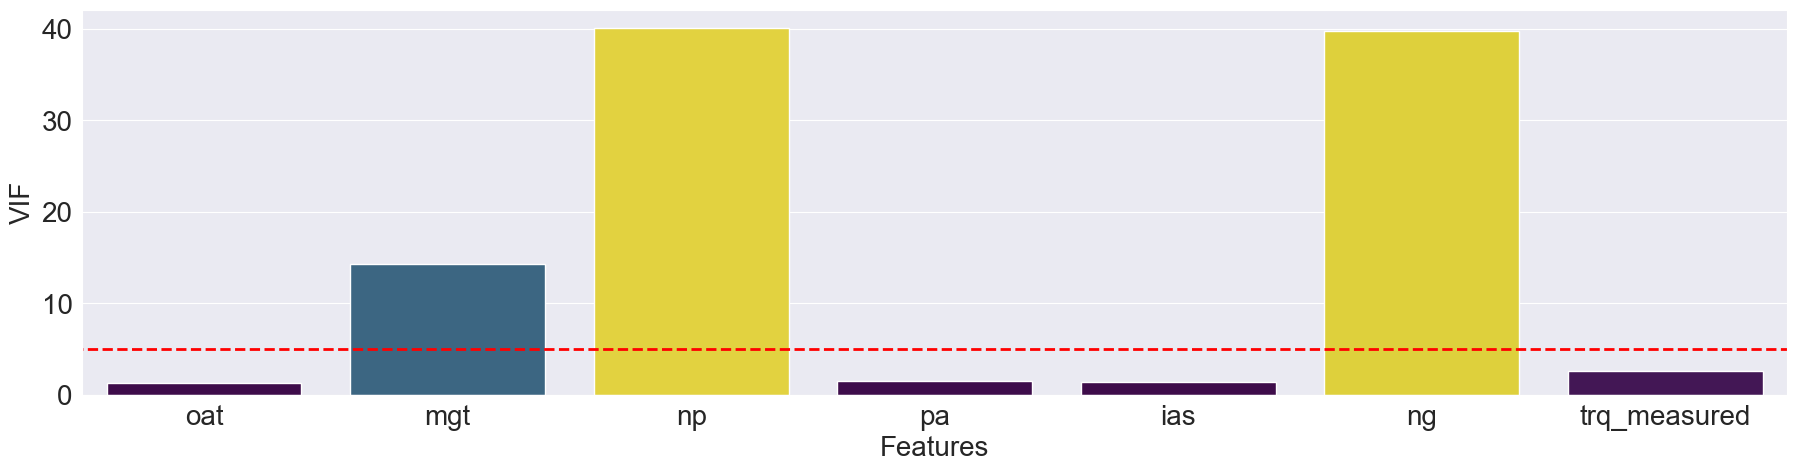

In [6]:
vif_df = df_x[['oat', 'mgt', 'np', 'pa', 'ias', 'ng', 'trq_measured']]
calculate_vif(vif_df)

In [7]:
osl_x = vif_df.drop(columns=['np']).assign(const=1)
osl_y = df_x['np']
np_osl_model = sm.OLS(osl_y, osl_x).fit()
print(np_osl_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     np   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                 4.831e+06
Date:                Wed, 12 Mar 2025   Prob (F-statistic):               0.00
Time:                        00:39:36   Log-Likelihood:            -7.1261e+05
No. Observations:              742625   AIC:                         1.425e+06
Df Residuals:                  742618   BIC:                         1.425e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
oat             -0.0006      0.000     -5.867   

-0.7891654004519081

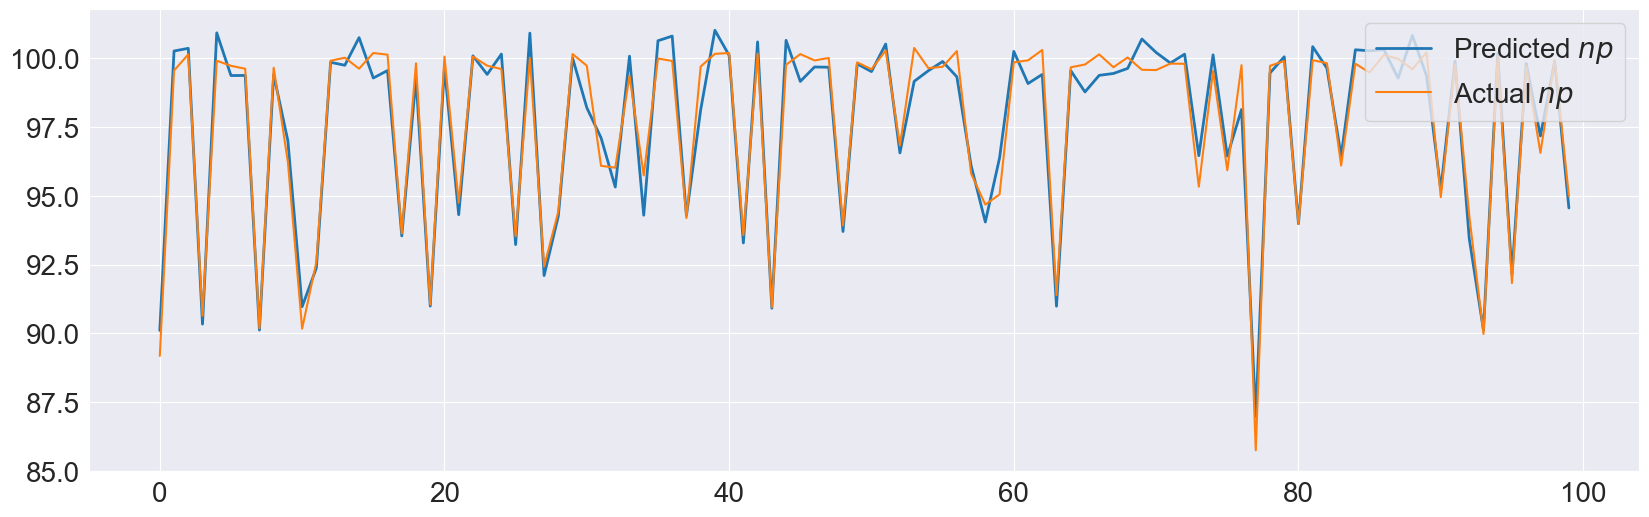

In [8]:
ax = pd.Series(np_osl_model.predict()[:100]).plot(figsize=(20, 6), label='Predicted $np$', linewidth=2)
(df_x['np'][:100]).plot(ax=ax, label='Actual $np$')
ax.legend(loc='upper right')
df_x['ng'].corr(df_x['np'])